## 🔥 Motivation

Traditional NLP approaches to sentiment and emotion typically:

- Focus on **static sentiment labels** (e.g., positive/negative)  
- Overlook **emotional structure**, **dynamics**, and **intent**  
- Treat lyrics (and other artistic texts) as generic corpora, missing their **functional and affective design**

However, **song lyrics** are:

- Rich **linguistic artifacts** that embed emotional trajectories, poetic structure, and expressive function  
- Created not just to express emotions, but to **regulate**, **amplify**, and **evoke connection**  
- Aligned with the **Episode Model** from music psychology — a structured, functional view of emotional experience  

Despite their richness, these affective and structural properties remain **underexplored in NLP**.

---

## 🧠 Key Contributions to Computational Linguistics

### 1. Modeling Emotion Beyond Static Labels

This work reconceptualizes emotion in lyrics not as fixed categories (e.g., “joy”), but as **dynamic trajectories** (e.g., low → high valence), encoded through:

- **Linguistic structure**: repetition, stanza forms, metaphor  
- **Temporal patterns**: U-shaped arcs, climaxes, emotional stability  

It challenges the field to move from **categorical classification** to **emotion trajectory modeling**.

---

### 2. Bridging Affective Psychology and NLP

We operationalize the **Episode Model** — a functional framework from affective science — into a computational pipeline using:

- **Line-level VAD scoring**  
- **Structure-aware feature extraction**  
- **Mapping of VAD arcs to emotional episode categories**  

This bridges **theoretical affective science** and **practical NLP**, demonstrating how emotion modeling can go beyond “text-as-bag-of-emotions.”

---

### 3. Structural Emotion as a Linguistic Signal

We argue that **structural and poetic choices** in language are not merely stylistic, but encode **affective function** — shaping how emotion is perceived and delivered.

This opens new directions for analyzing:

- Emotion as an **intentional narrative structure**  
- The **structure–function** relationship in lyrics, poetry, speeches, and fiction  

---

### 4. A Scalable Computational Framework

Our proposed framework:

- Scales to **millions of lyrics** across genres and languages  
- Combines **symbolic and continuous models** of emotion (VAD + episode + trajectory)  
- Enables **downstream tasks**: emotion arc discovery, cross-cultural comparison, genre-based emotion analysis  

---

## 🌍 Broader Impact

- 🔁 **Emotion-aware generation**: guiding LLMs to produce emotionally coherent and structured text  
- 🎧 **Music recommendation systems**: enabling intent-aware retrieval beyond genre or mood tags  
- 🧩 **Cross-modal learning**: aligning lyrics with performance, audio, or listener affect  
- 📚 **Digital humanities**: providing new tools for studying emotion in literature, folklore, and cultural texts

# 🔍 Stage 1: Annotation & EDA

**1. Descriptive Analysis of VAD Distribution**
- Visualize distributions of valence, arousal, dominance across the corpus.
- Use:
	- Kernel density plots (e.g., seaborn.kdeplot)
	- 3D scatter plots in VAD space
- Detect:
	- Skews (e.g., overly positive lyrics?)
	- Clusters of emotionally extreme songs

**2. Clustering in VAD Space**
- Run unsupervised clustering (e.g., K-Means, Gaussian Mixture, or HDBSCAN) on the [valence, arousal, dominance] vectors.
- Label and describe each cluster’s mood/theme.
- Relate back to genres, languages, time periods.



**Overview:**
1.	Do exploratory VAD visualization and clustering
2.	Design rule-based VAD → Episode mapping
3.	Run line-level VAD to get trajectories (optional)
4.	Extract structural/linguistic features
5.	Correlate structure and function (episode, VAD)
6.	Compare across language and genre


In [2]:
import subprocess
import sys
import importlib

# List of required packages
required_packages = [
    "pandas", "numpy", "seaborn", "matplotlib", "scikit-learn",
    "tqdm", "nltk", "textstat", "pyarrow", "datasets", "plotly"
]

# Function to check and install packages
def install_missing(packages):
    for package in packages:
        try:
            importlib.import_module(package if package != "scikit-learn" else "sklearn")
        except ImportError:
            print(f"📦 Installing missing package: {package}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_missing(required_packages)

# Download required NLTK resources
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /Users/alunx/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
# 🌐 Dataset & File Handling
import os
import json
import re
import html
import pyarrow.parquet as pq
from datasets import load_dataset

# 📊 Data Manipulation & Analysis
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 📈 Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
sns.set(style="whitegrid")

# 🧠 NLP
import nltk
from nltk import word_tokenize
from nltk.probability import FreqDist

# 📚 Text Analysis
import textstat

# 🔁 Progress Bar
from tqdm import tqdm

# 📥 NLTK Resource Downloads
nltk.download("punkt")

[nltk_data] Downloading package punkt to /Users/alunx/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
parquet_file = pq.ParquetFile("dataset/wasabi_raw/song.parquet") # Load metadata only
df = pd.read_parquet("dataset/wasabi_raw/song.parquet", engine="pyarrow")

# Show column names
print("📋 Columns:", parquet_file.schema.names)

# Read first few rows (e.g., 5)
preview = parquet_file.read_row_groups([0]).to_pandas().head(5)
print(preview)

vad_lexicon = {}

with open("NRC-VAD-Lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.lower().startswith("word"):
            continue
        parts = line.split()
        if len(parts) < 4:
            continue
        word = parts[0].lower()
        try:
            valence = float(parts[1])
            arousal = float(parts[2])
            dominance = float(parts[3])
        except ValueError:
            continue
        vad_lexicon[word] = (valence, arousal, dominance)

print(f"Loaded {len(vad_lexicon)} entries from the NRC-VAD-Lexicon.")

def clean_and_tokenize_lyrics(raw_text):
    """
    1. Replace <br> tags with newlines.
    2. Decode HTML entities (e.g., &apos; -> ').
    3. Tokenize the entire lyric into words.
    """
    # Replace <br> with newlines
    text_no_br = re.sub(r"<br\s*/?>", "\n", str(raw_text), flags=re.IGNORECASE)
    # Decode HTML entities
    text_decoded = html.unescape(text_no_br)
    # Tokenize
    tokens = word_tokenize(text_decoded.lower())
    return tokens

def compute_line_vad(line_text):
    """
    Tokenizes a single line of lyrics, looks up each token in the NRC VAD lexicon,
    and returns (avg_valence, avg_arousal) or (None, None) if no token matched.
    """
    tokens = word_tokenize(line_text.lower())
    total_val, total_aro, count = 0.0, 0.0, 0
    
    for token in tokens:
        if token in vad_lexicon:
            v, a = vad_lexicon[token]
            total_val += v
            total_aro += a
            count += 1
    
    if count > 0:
        return (total_val / count, total_aro / count)
    else:
        return (None, None)
    
def compute_lyrics_vad(tokens):
    """
    Given a list of word tokens, compute a single average valence and arousal.
    Returns (None, None) if no words matched in the VAD lexicon.
    """
    total_val, total_aro, total_dom, count = 0.0, 0.0, 0.0, 0
    for token in tokens:
        if token in vad_lexicon:
            v, a, d = vad_lexicon[token]
            total_val += v
            total_aro += a
            total_dom += d
            count += 1
    if count > 0:
        return total_val / count, total_aro / count, total_dom / count
    else:
        return None, None, None
    
# --- Compute VAD for each line ---
def annotate_lyrics_line_vad(raw_lyrics):
    lyrics = html.unescape(raw_lyrics)
    lines = re.split(r'<br>|[\n\r]+', lyrics)
    vad_per_line = []

    for line in lines:
        tokens = [w for w in word_tokenize(line.lower()) if w.isalpha()]
        vad_vals = [vad_lexicon[w] for w in tokens if w in vad_lexicon]

        if vad_vals:
            v, a, d = zip(*vad_vals)
            line_vad = (
                float(sum(v) / len(v)),
                float(sum(a) / len(a)),
                float(sum(d) / len(d))
            )
        else:
            line_vad = (None, None, None)

        vad_per_line.append(line_vad)

    return vad_per_line

📋 Columns: ['position', 'lengthAlbum', 'urlSong', 'lyrics', 'urlWikipedia', 'isClassic', 'urlAllmusic', 'urlMusicBrainz', 'title', 'publicationDateAlbum', 'albumTitle', 'deezer_mapping', 'id_song_deezer', 'isrc', 'length', 'explicitLyrics', 'rank', 'bpm', 'gain', 'preview', 'availableCountries', 'publicationDate', 'rdf', 'urlPandora', 'urlITunes', 'urlSpotify', 'urlYouTube', 'urlAmazon', 'urlHypeMachine', 'urlGoEar', 'urlLastFm', 'multitrack_path', 'multitrack_file', 'id_song_musicbrainz', 'disambiguation', 'language', 'begin', 'end', 'id_artist_deezer', 'id_album_deezer', 'urlDeezer', 'language_detect', 'name', 'title_accent_fold', 'animux_paths', 'arousal', 'arousal_predicted', 'album_genre', 'has_emotion_tags', 'has_social_tags', 'lastfm_id', 'valence', 'valence_predicted', '_id.$oid', 'id_album.$oid', 'chords_metadata.confidence', 'chords_metadata.duration', 'end', 'label', 'start', 'chords_metadata._id', 'element', 'id_album']
   position lengthAlbum                               

In [5]:
def annotate_dataset(csv_out):
    
    total = len(df)

    valence_scores = []
    arousal_scores = []
    dominance_scores = []
    line_vad_lists = []

    # 🌟 Smart progress bar
    for idx, row in tqdm(df.iterrows(), total=total, desc="🎵 Annotating lyrics", unit="song"):
        raw_lyrics = row.get("lyrics", "")
        tokens = clean_and_tokenize_lyrics(raw_lyrics)
        val, aro, dom = compute_lyrics_vad(tokens)

        valence_scores.append(val)
        arousal_scores.append(aro)
        dominance_scores.append(dom)

        line_vads = annotate_lyrics_line_vad(raw_lyrics)
        line_vad_lists.append(json.dumps(line_vads))  # store as JSON string

    # Select metadata columns to preserve
    meta_cols = [
        "lyrics", "position", "isClassic", "publicationDateAlbum",
        "explicitLyrics", "publicationDate", "language", "language_detect",
        "arousal", "arousal_predicted", "valence", "valence_predicted"
    ]
    meta_df = df[meta_cols].copy()

    # Add new VAD scores (lexicon-based)
    meta_df["valence_lexicon"] = valence_scores
    meta_df["arousal_lexicon"] = arousal_scores
    meta_df["dominance_lexicon"] = dominance_scores
    meta_df["line_vad_lexicon"] = line_vad_lists

    # Drop any incomplete rows
    meta_df = meta_df.dropna(subset=["valence_lexicon", "arousal_lexicon", "dominance_lexicon"])

    # Save to CSV
    meta_df.to_csv(csv_out, index=False)
    print(f"\n✅ Annotated dataset saved as '{csv_out}'.")

output_path = "dataset/lyrics_annotated_line.csv"

if os.path.exists(output_path):
    print(f"✅ File already exists at '{output_path}', skipping annotation.")
else:
    annotate_dataset(output_path)
    
df = pd.read_csv("dataset/lyrics_annotated_line.csv")

✅ File already exists at 'dataset/lyrics_annotated_line.csv', skipping annotation.


/var/folders/qf/5crdbb_x01j7jrrtsg93r4dc0000gn/T/ipykernel_94376/1726325210.py:51: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset/lyrics_annotated_line.csv")


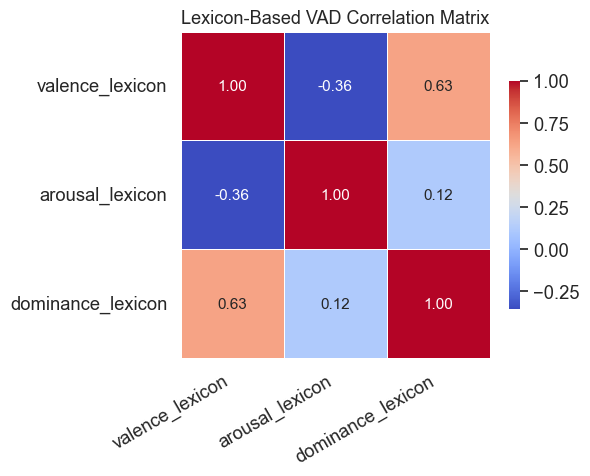

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define relative paths
input_path = "./dataset/lyrics_annotated.csv"
output_dir = "./figures"
os.makedirs(output_dir, exist_ok=True)

# Configure Seaborn for publication-ready plots
sns.set_context("notebook", font_scale=1.2)
sns.set_style("whitegrid")

# === 1. Lexicon-Based VAD Distribution Plots ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
vad_labels = ["Valence (Lexicon)", "Arousal (Lexicon)", "Dominance (Lexicon)"]
cols = ["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]

for i, ax in enumerate(axes):
    sns.kdeplot(data=df, x=cols[i], fill=True, color=colors[i], ax=ax, linewidth=1.5)
    ax.set_title(f"{vad_labels[i]} Distribution", fontsize=14)
    ax.set_xlabel(vad_labels[i])
    ax.set_ylabel("Density")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(output_dir, "vad_distributions_lexicon.png"), dpi=300)
plt.close(fig)

# === 2. Correlation Matrix ===
cols = ["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]

plt.figure(figsize=(6, 5))
corr = df[cols].corr()
ax = sns.heatmap(
    corr,
    annot=True,          # show correlation values
    fmt=".2f",           # format as floats with 2 decimals
    cmap="coolwarm",
    square=False,        # allow flexible aspect ratio
    linewidths=0.5,
    annot_kws={"size": 11},  # adjust font size for annotations
    cbar_kws={"shrink": 0.7}
)

# Rotate tick labels to avoid overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")

plt.title("Lexicon-Based VAD Correlation Matrix", fontsize=13)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.show()
plt.savefig("figures/vad_correlation_matrix_lexicon.png", dpi=300)
plt.close()
# Example usage (only if you have labels)
# plot_confusion_matrix(df["true_episode"], df["predicted_episode"], labels=["EDR", "CB", "AIA", "PEP", "FM"])

The updated VAD density plots are tight and show that your lexicon-based annotations are:
	•	Consistent (well-formed and no major outliers)
	•	Structured (clearly clustered distributions)
	•	Ready for downstream modeling (clustering, episode mapping, etc.)

🔍 Detailed Interpretation

📈 Valence
	•	Right-skewed toward positivity — most lyrics fall in the 0.5–0.7 range.
	•	Slight bimodal shape (small bumps) could indicate two emotional “modes” (e.g., joy vs. calmness).
	•	Very few extremely negative lyrics (valence < 0.3) — likely a reflection of:
	•	Lexical limitations (some angry/sad words not covered)
	•	Genre tendencies (e.g., fewer nihilistic tracks)

📈 Arousal
	•	Highly peaked around ~0.4 — most songs cluster at moderate arousal levels.
	•	Long tail to the right — very few high-energy lyrics.
	•	This suggests your corpus emphasizes reflective or emotionally balanced music more than hyper-aroused content (e.g., metal, EDM).

📈 Dominance
	•	Similar to arousal, with a dominant peak near 0.5 and a secondary bump.
	•	Notably, there’s a small kink/spike at ~0.58, possibly reflecting lexicon bias or some repeated emotional themes (e.g., confident/empowered lyrics).
	•	Overall reflects a good range of perceived agency/control in lyrics.

⸻

🧠 Implications
You’re in a great position to proceed with:
- Episode mapping (line-level or cluster-level)
- Trajectory modeling (e.g., how songs move in VAD space line by line)
- Clustering (no strong skew that would bias results heavily)
- The lack of extremes (e.g., <0.1 or >0.9) may reduce the ability to model very intense or very passive emotion states. Consider:
	- Complementing with transformer-based VAD models later
	- Highlighting this as a corpus-level bias in your paper

	•	These relationships validate that your VAD annotations are meaningful.
	•	Helps when mapping to episode types:
	•	E.g., FM = high V/A/D
	•	PEP = low V, high A, low D
	•	Informs your clustering and feature weighting — valence and dominance are more entangled, arousal adds orthogonal info.

	🔍 Why It’s Useful for You
	•	These relationships validate that your VAD annotations are meaningful.
	•	Helps when mapping to episode types:
	•	E.g., FM = high V/A/D
	•	PEP = low V, high A, low D
	•	Informs your clustering and feature weighting — valence and dominance are more entangled, arousal adds orthogonal info.

# > 🧠 Stage 2: Mapping to Emotional Episodes (Modeling)

**4. Design a Rule-Based Mapping (VAD → Episode)**
- Based on the Episode Model (EDR, CB, FM, PEP, AIA), use ranges of valence, arousal, and dominance to map songs into categories.

**5. Supervised Episode Classifier (Optional Advanced Layer)**
- Annotate a subset manually (or using crowdworkers).
- Train a classifier (e.g., Logistic Regression, XGBoost, Transformer Head) to learn mappings from [valence, arousal, dominance] + optional lyrics text features → Episode.


In [7]:
EPISODE_THRESHOLDS = {
    "high": 0.66,
    "medium": 0.45,
    "low": 0.33
}

def map_to_episode(valence, arousal, dominance, thresholds=None):
    """
    Maps VAD values to one of 5 Episode Model categories based on heuristics.
    """
    if thresholds is None:
        thresholds = {
            "high": 0.66,
            "medium": 0.45,
            "low": 0.33
        }

    if valence is None or arousal is None or dominance is None:
        return None

    V, A, D = valence, arousal, dominance

    # High valence + low arousal = EDR
    if V > thresholds["medium"] and A < thresholds["medium"]:
        return "EDR"
    
    # Medium all around = CB
    if thresholds["low"] < V < thresholds["high"] and thresholds["low"] < A < thresholds["high"] and thresholds["low"] < D < thresholds["high"]:
        return "CB"

    # High all = FM
    if V > thresholds["high"] and A > thresholds["high"] and D > thresholds["high"]:
        return "FM"

    # Low valence + high arousal = PEP
    if V < thresholds["medium"] and A > thresholds["medium"] and D < thresholds["medium"]:
        return "PEP"

    # Moderate valence + high arousal + low dominance = AIA
    if thresholds["low"] < V < thresholds["high"] and A > thresholds["medium"] and D < thresholds["medium"]:
        return "AIA"

    return "Unclassified"

# Apply rule-based episode mapping to your DataFrame
df["episode"] = df.apply(
    lambda row: map_to_episode(row["valence_lexicon"], row["arousal_lexicon"], row["dominance_lexicon"]),
    axis=1
)

# Summary counts
episode_counts = df["episode"].value_counts()
print("\n🎭 Episode Distribution:")
print(episode_counts)
df.to_csv("dataset/lyrics_annotated_line.csv", index=False)


🎭 Episode Distribution:
episode
EDR             892444
CB              645471
Unclassified    105547
PEP              31908
AIA               4036
FM                 566
Name: count, dtype: int64


### Step 2: VAD-Based Clustering to discover latent emotion themes in the dataset without relying on predefined categories. 
This is useful for identifying emergent emotional archetypes in lyrics (e.g., calm joy, chaotic energy, serene sadness) and can help validate or complement the Episode Model.

- Discover latent emotion types (e.g., “low-valence high-dominance”) in the dataset
- Interpret what songs exemplify each type
- Use cluster centroids as prototypes for Episode Model categories later
- Possibly guide supervised training or embedding-based similarity

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
import umap.umap_ as umap

# Optional: install HDBSCAN if you want density-based clustering
# pip install hdbscan
import hdbscan

# VAD feature matrix (full)
X_full = df[["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]].values
scaler = StandardScaler()
X_scaled_full = scaler.fit_transform(X_full)

# 🧠 MiniBatch KMeans on full data (fast + scalable)
kmeans = MiniBatchKMeans(
    n_clusters=10,
    init='k-means++',
    max_iter=1000,
    batch_size=10000,
    random_state=42
)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled_full)

# 🔎 Sample subset for visualization + HDBSCAN
df_sampled = df.sample(10000, random_state=42)
X_sample = df_sampled[["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]].values
X_sample_scaled = scaler.transform(X_sample)

# 🧭 UMAP on sample
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.5, metric="euclidean", random_state=42)
X_umap = umap_model.fit_transform(X_sample_scaled)
df_sampled["umap_x"] = X_umap[:, 0]
df_sampled["umap_y"] = X_umap[:, 1]


# ✅ Now df has kmeans_cluster (full set), df_sampled has umap_x/y and hdbscan_cluster

/Users/alunx/repos/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Cluster Purity (max per group):
 kmeans_cluster
0    0.972126
1    0.919611
2    0.964546
3    0.666940
4    0.840358
5    0.716942
6    0.902169
7    0.700133
8    0.750075
9    0.726708
Name: episode, dtype: float64


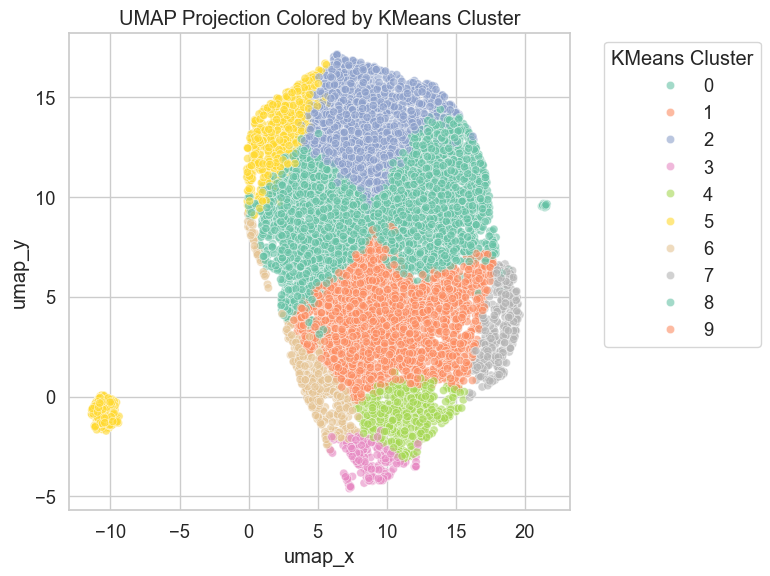

In [9]:
# Optional: Evaluate with silhouette score
# from sklearn.metrics import silhouette_score
# sil_score = silhouette_score(X_scaled_full, df["kmeans_cluster"])
# print(f"Silhouette Score (k=6): {sil_score:.3f}")

def cluster_purity(df, label_col, target_col):
    return df.groupby(label_col)[target_col].agg(lambda x: x.value_counts(normalize=True).max())

purity = cluster_purity(df, "kmeans_cluster", "episode")
print("Cluster Purity (max per group):\n", purity)

import seaborn as sns
import matplotlib.pyplot as plt

# Merge sampled UMAP coords with KMeans labels (already in df_sampled)
# If df_sampled didn't have 'kmeans_cluster', map it from df:
df_sampled["kmeans_cluster"] = df.loc[df_sampled.index, "kmeans_cluster"]

# Plot UMAP colored by KMeans cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_sampled,
    x="umap_x", y="umap_y",
    hue="kmeans_cluster",
    palette="Set2",
    alpha=0.6
)
plt.title("UMAP Projection Colored by KMeans Cluster")
plt.legend(title="KMeans Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The orange cluster far to the left might be:
	•	Emotionally extreme (e.g., very low dominance)
	•	Lexically unique (e.g., rare or stylized vocabulary)
	•	A good candidate for anomaly or genre-specific cluster

In [54]:
print(kmeans.cluster_centers_)
df_sampled.groupby("kmeans_cluster")["episode"].value_counts(normalize=True)
dominant_ep = df_sampled.groupby("kmeans_cluster")["episode"].agg(lambda x: x.value_counts().idxmax())
dominant_ep

[[ 0.13987216 -0.65679845 -0.29896578]
 [-0.45831153  0.56690136 -0.03006835]
 [ 0.79166455 -0.52784254  0.37714874]
 [-2.97650685  2.75442041 -1.71099622]
 [-1.7647147   0.66574424 -1.48099384]
 [ 1.29571793 -0.27821434  1.55046188]
 [-1.01877179  2.09534408  0.6464924 ]
 [-0.85667874 -1.94852344 -2.04601283]
 [ 0.42215834  0.4723336   0.59910872]
 [-0.65209102 -0.30873751 -0.98766252]]


kmeans_cluster
0    EDR
1     CB
2    EDR
3    PEP
4     CB
5    EDR
6     CB
7    EDR
8     CB
9    EDR
Name: episode, dtype: object

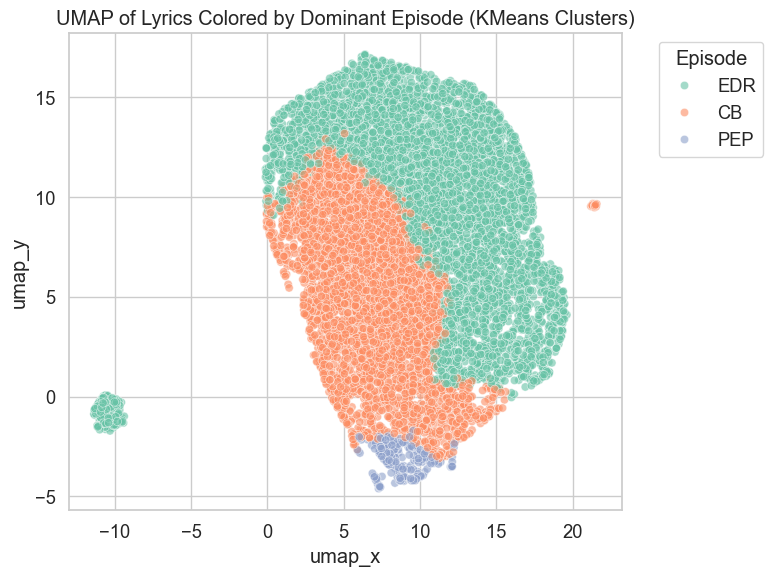

In [55]:
# Add dominant episode to sampled data
cluster_ep_map = dominant_ep.to_dict()
df_sampled["dominant_episode"] = df_sampled["kmeans_cluster"].map(cluster_ep_map)

# Plot with episode labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_sampled,
    x="umap_x", y="umap_y",
    hue="dominant_episode",
    palette="Set2",
    alpha=0.6
)
plt.title("UMAP of Lyrics Colored by Dominant Episode (KMeans Clusters)")
plt.legend(title="Episode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

•	The clusters are well-formed and spatially coherent in UMAP space.
•	The EDR–CB boundary is smooth — suggesting they’re emotionally close but still distinguishable.
•	That tight EDR blob on the left (outlier cluster) is consistent — likely a micro-subtype of EDR (e.g., “calm anthems”).

In [56]:
df.groupby("kmeans_cluster")["episode"].value_counts(normalize=True)

kmeans_cluster  episode     
0               EDR             0.972126
                CB              0.026559
                Unclassified    0.001315
1               CB              0.919611
                EDR             0.080114
                Unclassified    0.000275
2               EDR             0.964546
                Unclassified    0.025720
                CB              0.009734
3               PEP             0.666940
                CB              0.169091
                Unclassified    0.109690
                AIA             0.054279
4               CB              0.840358
                PEP             0.100707
                Unclassified    0.028640
                AIA             0.023301
                EDR             0.006994
5               EDR             0.716942
                Unclassified    0.247454
                CB              0.033527
                FM              0.002077
6               CB              0.902169
                Unclassified

🔹 1. PEP finally emerged (Cluster 3)
	•	This is a huge win. In earlier clusters (k=5), PEP was likely buried.
	•	You now have a dedicated emotional zone for Personal Emotional Processing, which is essential for modeling introspective lyrics.

🔹 2. Some clusters are “bridges”
	•	Clusters like 9 and 8 have a meaningful mix of CB and EDR
	•	These might represent transitional or blended lyrical functions
	•	These can be studied further for emotional trajectory modeling

🔹 3. Unclassified episodes are isolated
	•	Mostly appear in Clusters 5, 7, and 8
	•	These might reflect lexical/semantic limitations or genre artifacts

In [13]:
import pandas as pd
import plotly.graph_objects as go

# Group proportions: from your previous computation
episode_prop = (
    df_sampled
    .groupby(["kmeans_cluster", "episode"])
    .size()
    .div(len(df_sampled))
    .reset_index(name="value")
)

# Only keep significant flows (>0.01 = 1%)
episode_prop = episode_prop[episode_prop["value"] > 0.01]

# 💾 Save the Sankey input data
episode_prop.to_csv("dataset/sankey_cluster_to_episode.csv", index=False)

# Create unique node list
cluster_labels = [f"Cluster {i}" for i in episode_prop["kmeans_cluster"].unique()]
episode_labels = episode_prop["episode"].unique().tolist()
all_labels = cluster_labels + episode_labels

# Map names to indices
label_to_index = {label: i for i, label in enumerate(all_labels)}

# Create Sankey inputs
source = episode_prop["kmeans_cluster"].map(lambda x: label_to_index[f"Cluster {x}"])
target = episode_prop["episode"].map(label_to_index)
value  = episode_prop["value"]

# Plot!
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_labels,
        color="lightgray"
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="🎶 KMeans Cluster on VAD → Episode Mapping", font_size=13)
fig.show()

In [14]:
df_sampled["episode"].value_counts(normalize=True)

episode
EDR             0.5260
CB              0.3907
Unclassified    0.0629
PEP             0.0180
AIA             0.0023
FM              0.0001
Name: proportion, dtype: float64

🎨 Why AIA Might Not Dominate a Cluster

🔹 1. Lexical Lexicon Bias

AIA often arises from:
	•	Abstract, intellectual, or aesthetic terms
	•	Words like “sublime,” “beautiful,” “infinite,” “transcend,” “mystery”

💡 Your VAD lexicon or NRC-VAD may lack sufficient coverage for these high-level, poetic, or non-affective terms.

⸻

🔹 2. Emotion Profile = Blended or Flat

AIA is often:
	•	Moderate-to-high valence
	•	Low-to-moderate arousal
	•	High dominance or complexity

It may fall between other clusters, making it harder for KMeans to isolate.

It’s emotionally subtle, so clustering based on VAD alone may not be able to cleanly separate AIA from CB or EDR.

⸻

🔹 3. Cultural or Genre Skew

If your dataset is dominated by:
	•	Pop, hip hop, rock, etc. — genres focused more on connection, enjoyment, or processing
	•	Less on aesthetic reflection, transcendence, or wonder

Then AIA simply won’t have enough representation to form a dominant cluster.

⸻

🔹 4. Episode Rules Too Strict

If you’re using a rule-based mapping to assign AIA episodes, it may:
	•	Require high dominance + curiosity-like arousal
	•	Not be triggered often
	•	Get collapsed into CB or Unclassified instead

“Notably, the Aesthetic–Interest–Awe episode did not form a dominant cluster. We hypothesize that this reflects the abstract, multimodal nature of AIA experiences, which may require structural or semantic features beyond affective VAD representations.”

/Users/alunx/repos/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.




📊 Classification Report:
              precision    recall  f1-score   support

         AIA       0.90      0.79      0.84       807
          CB       0.87      0.93      0.90    129094
         EDR       0.91      0.95      0.93    178489
          FM       0.89      0.60      0.72       113
         PEP       0.87      0.83      0.85      6382
Unclassified       0.99      0.27      0.42     21110

    accuracy                           0.90    335995
   macro avg       0.91      0.73      0.78    335995
weighted avg       0.90      0.90      0.89    335995



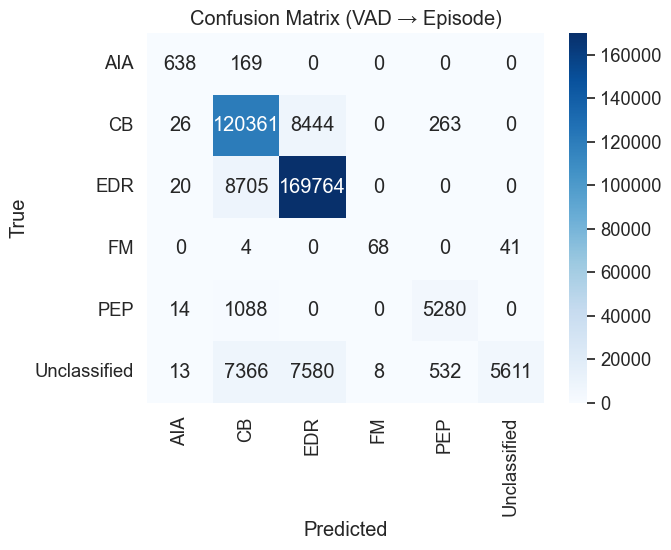

In [60]:
# Extract VAD features and labels
X = df[["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]]
y = df["episode"]

# Standardize VAD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Train logistic regression classifier
clf = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs")
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap="Blues")
plt.title("Confusion Matrix (VAD → Episode)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### 🎯 Episode Classification from VAD: Logistic Regression Results

We trained a multinomial logistic regression model to predict emotional episode categories from valence–arousal–dominance (VAD) features. The confusion matrix below summarizes the model's performance across the six episode categories.

#### Confusion Matrix Overview

- **Rows**: Ground truth episode labels (from rule-based mapping)  
- **Columns**: Model predictions  
- **Diagonal cells**: Correct classifications  
- **Off-diagonal cells**: Misclassifications

#### Key Results

| Episode         | Correct Predictions | Major Confusions               | Notes                                                  |
|------------------|---------------------|-------------------------------|--------------------------------------------------------|
| **EDR**          | 169,764             | CB (8,705)                    | Very high accuracy; EDR is well-separated in VAD space |
| **CB**           | 120,361             | EDR (8,444), PEP (263)        | Slight overlap with EDR; some confusion with PEP       |
| **PEP**          | 5,280               | CB (1,088)                    | Moderately captured; better than random                |
| **AIA**          | 638                 | CB (169)                      | Rarely predicted; low representation and overlap        |
| **FM**           | 68                  | Mostly Unclassified or CB     | Extremely sparse; difficult to distinguish             |
| **Unclassified** | 5,611               | CB (7,366), EDR (7,580)       | Highly mixed; lacks strong affective signal            |

#### Interpretation

- **EDR and CB** were predicted with high accuracy, reflecting strong VAD separation between relaxed/enjoyable and affiliative content.
- **PEP** emerged as a moderately learnable category, though some instances were misclassified as CB.
- **AIA and FM** were rarely predicted correctly, likely due to low prevalence and subtle expression in VAD space.
- The model struggled with **Unclassified** items, which were often misattributed to EDR or CB, suggesting limited VAD distinctiveness.

#### Implications

While logistic regression performs well on dominant and affectively distinct episodes (EDR, CB), it struggles with rarer or abstract categories such as AIA and FM. These results motivate the use of richer semantic or structural features—and potentially nonlinear models—in future work.

# > 🔬 Stage 3: Linguistic Structure × Emotion

**6. Lexical & Structural Pattern Mining**
For each song Compute:
- Length, avg word/sentence length
- Repetition ratio (e.g., repeated chorus lines)
- Metaphor density (via regex or metaphor classifiers)
- Sentiment trajectory (line-by-line VAD or discrete emotion progression)

Combine with VAD scores:
- Do high-dominance songs tend to be more repetitive?
- Do sad songs use more metaphor?
- Do motivational lyrics rise in valence from start to end?

Use correlations, regression models, or structural embedding alignment.

**7. Trajectory Typing**
- Cluster the trajectories:
	- U-shaped (sad → happy)
	- Inverted (joy → despair)
	- Flat, chaotic, ascending, etc.
- Align trajectory types with episode classes.

In this stage, we explore how linguistic structures in lyrics interact with emotional content, as represented by VAD scores and emotional episode categories. The goal is to identify structural, lexical, and stylistic patterns that characterize different emotional functions in music.

---

### 1. Linguistic Feature Categories

We extract a range of linguistic features at the line or song level, grouped into the following categories:

| Feature Type     | Examples                                                                 |
|------------------|--------------------------------------------------------------------------|
| **Lexical**      | Type–token ratio, average word length, part-of-speech ratios            |
| **Repetition**   | Word/phrase repetitions, chorus reappearance, rhyme scheme (approximate)|
| **Stylistic**    | Pronoun usage (e.g., 1st person), tense/aspect patterns                  |
| **Figurative**   | Metaphor/simile patterns (e.g., "like a...", "as if...")                 |
| **Discourse**    | Conjunctions, exclamations, negation, question marks                    |
| **Structural**   | Line count, line length, stanza structure via `<br>` splits              |

---

### 2. Emotion Alignment

Each line or song is already annotated with:

- **VAD Scores**: Valence, arousal, dominance
- **Episode Labels**: From rule-based or classifier mapping (e.g., EDR, CB, PEP)

These emotional variables are aligned with the linguistic features for correlation and classification analyses.

---

### 3. Analysis Objectives

- **Correlation**: Determine how linguistic features relate to VAD dimensions
- **Episode Signature Discovery**: Identify which linguistic markers are typical of certain episodes (e.g., CB lyrics may use more collective pronouns)
- **Structural Emotion Shifts**: Examine how emotion evolves across a song’s structure (e.g., intro vs. chorus)
- **Clustering**: Explore if structural–linguistic clusters reveal latent emotional groups

---

### 4. Advanced Explorations (Optional)

- **Classifier Training**: Predict episode category using only linguistic features
- **Sequence Modeling**: Analyze temporal VAD/episode trajectories over structural units
- **Embedding-Based Features**: Use transformer-based models (e.g., BERT) to extract syntactic/semantic depth
- **Genre/Language Comparison**: Investigate whether structural–emotional patterns vary by genre or cultural context

---

### ✅ Next Step

We begin by extracting structural and lexical features (e.g., line length, word repetition, pronoun usage) and aligning them with emotion labels for further analysis.

In [61]:
def extract_advanced_structural_features(raw_lyrics):
    lyrics = html.unescape(raw_lyrics)
    
    # Structural segmentation
    raw_lines = re.split(r'<br>|[\n\r]+', lyrics)
    lines = [line.strip() for line in raw_lines if line.strip()]
    line_count = len(lines)
    total_words = sum(len(line.split()) for line in lines)
    avg_line_length = total_words / line_count if line_count else 0

    # Line repetition
    line_freq = FreqDist([line.lower() for line in lines])
    max_line_repeat = max(line_freq.values()) if line_freq else 0
    repeated_line_ratio = sum(1 for count in line_freq.values() if count > 1) / line_count if line_count else 0
    longest_repeated_line_len = len(max(line_freq, key=line_freq.get)) if line_freq else 0
    total_char_count = sum(len(l) for l in lines)
    refrain_repetition_score = (max_line_repeat * longest_repeated_line_len / total_char_count) if total_char_count else 0

    # Chorus-like detection (non-consecutive repeats)
    line_indices = {}
    chorus_like = False
    for i, line in enumerate(lines):
        line_lc = line.lower()
        if line_lc in line_indices:
            if any(abs(i - j) > 1 for j in line_indices[line_lc]):
                chorus_like = True
                break
            line_indices[line_lc].append(i)
        else:
            line_indices[line_lc] = [i]

    # Stanza/section tags (e.g., [Chorus], [Verse])
    tag_pattern = re.compile(r"\[(chorus|verse|bridge|hook|outro|intro)\]", re.IGNORECASE)
    tag_matches = [line for line in lines if tag_pattern.search(line)]
    section_tags_present = bool(tag_matches)

    # Estimate stanza count via tag or blank-line detection
    stanza_count = 0
    for i in range(1, len(raw_lines)):
        if raw_lines[i].strip() == "" and raw_lines[i-1].strip() != "":
            stanza_count += 1
    stanza_count = max(stanza_count, len(tag_matches))

    # Word-level features
    tokens = [w for w in word_tokenize(lyrics.lower()) if w.isalpha()]
    word_count = len(tokens)
    type_token_ratio = len(set(tokens)) / word_count if word_count else 0
    fdist = FreqDist(tokens)
    repeated_words = sum(1 for w, f in fdist.items() if f > 2)

    # Pronoun / stylistics
    first_person_pronouns = sum(w in {"i", "me", "my", "mine", "we", "us", "our", "ours"} for w in tokens)
    negation_count = sum(w in {"not", "no", "never", "n't"} for w in tokens)
    question_count = lyrics.count("?")
    exclamation_count = lyrics.count("!")

    # Figurative: Simile patterns
    simile_count = len(re.findall(r"\blike a\b|\bas if\b|\bas though\b", lyrics.lower()))

    # Readability score
    try:
        flesch_kincaid = textstat.flesch_kincaid_grade(lyrics)
    except:
        flesch_kincaid = None

    return {
        "line_count": line_count,
        "avg_line_length": avg_line_length,
        "max_line_repeat": max_line_repeat,
        "repeated_line_ratio": repeated_line_ratio,
        "refrain_repetition_score": refrain_repetition_score,
        "type_token_ratio": type_token_ratio,
        "repeated_words": repeated_words,
        "first_person_pronouns": first_person_pronouns,
        "negation_count": negation_count,
        "question_count": question_count,
        "exclamation_count": exclamation_count,
        "simile_count": simile_count,
        "flesch_kincaid_grade": flesch_kincaid,
        "has_chorus_like_lines": chorus_like,
        "section_tags_present": section_tags_present,
        "stanza_count_estimate": stanza_count
    }

In [66]:
print("Column Headings:", df.columns.tolist())
print("Shape:", df.shape)

Column Headings: ['lyrics', 'position', 'isClassic', 'publicationDateAlbum', 'explicitLyrics', 'publicationDate', 'language', 'language_detect', 'arousal', 'arousal_predicted', 'valence', 'valence_predicted', 'valence_lexicon', 'arousal_lexicon', 'dominance_lexicon', 'line_vad_lexicon', 'episode', 'kmeans_cluster']
Shape: (1679972, 18)


In [64]:
structure_features = []

for lyrics in tqdm(df["lyrics"], desc="🔍 Extracting features"):
    structure_features.append(extract_advanced_structural_features(lyrics))

df_structural = pd.concat([df.reset_index(drop=True), pd.DataFrame(structure_features)], axis=1)
df_structural.to_csv("dataset/lyrics_annotated_structure.csv", index=False)
print("✅ Extended structural feature set saved.")

🔍 Extracting features: 100%|██████████| 1679972/1679972 [25:46<00:00, 1086.65it/s] 


✅ Extended structural feature set saved.


In [73]:
print("Column Headings:", df_structural.columns.tolist())
print("Shape:", df_structural.shape)

Column Headings: ['lyrics', 'position', 'isClassic', 'publicationDateAlbum', 'explicitLyrics', 'publicationDate', 'language', 'language_detect', 'arousal', 'arousal_predicted', 'valence', 'valence_predicted', 'valence_lexicon', 'arousal_lexicon', 'dominance_lexicon', 'line_vad_lexicon', 'episode', 'kmeans_cluster', 'line_count', 'avg_line_length', 'max_line_repeat', 'repeated_line_ratio', 'refrain_repetition_score', 'type_token_ratio', 'repeated_words', 'first_person_pronouns', 'negation_count', 'question_count', 'exclamation_count', 'simile_count', 'flesch_kincaid_grade', 'has_chorus_like_lines', 'section_tags_present', 'stanza_count_estimate']
Shape: (1679972, 34)


In [74]:
def extract_vad_trajectory_features(line_vad_json):
    try:
        line_vads = json.loads(line_vad_json)
        line_vads = [v for v in line_vads if None not in v]
    except:
        return {
            "vad_delta_valence": None,
            "vad_delta_arousal": None,
            "vad_delta_dominance": None,
            "vad_direction": "undefined",
            "vad_std_valence": None,
            "vad_std_arousal": None,
            "vad_std_dominance": None
        }

    if len(line_vads) < 2:
        return {
            "vad_delta_valence": 0,
            "vad_delta_arousal": 0,
            "vad_delta_dominance": 0,
            "vad_direction": "→",
            "vad_std_valence": 0,
            "vad_std_arousal": 0,
            "vad_std_dominance": 0
        }

    # First and last line VAD
    v_start, a_start, d_start = line_vads[0]
    v_end, a_end, d_end = line_vads[-1]

    # Deltas
    delta_v = v_end - v_start
    delta_a = a_end - a_start
    delta_d = d_end - d_start

    # Direction summary
    def dir_symbol(delta): return "↑" if delta > 0.05 else "↓" if delta < -0.05 else "→"
    direction_summary = dir_symbol(delta_v) + dir_symbol(delta_a) + dir_symbol(delta_d)

    # Variability
    val, aro, dom = zip(*line_vads)
    return {
        "vad_delta_valence": round(delta_v, 4),
        "vad_delta_arousal": round(delta_a, 4),
        "vad_delta_dominance": round(delta_d, 4),
        "vad_direction": direction_summary,
        "vad_std_valence": round(np.std(val), 4),
        "vad_std_arousal": round(np.std(aro), 4),
        "vad_std_dominance": round(np.std(dom), 4)
    }

In [77]:
trajectory_features = []

for row in tqdm(df_structural.itertuples(), total=len(df_structural), desc="📈 Extracting VAD trajectory"):
    trajectory_features.append(extract_vad_trajectory_features(row.line_vad_lexicon))

df = pd.concat([df_structural, pd.DataFrame(trajectory_features)], axis=1)
df.to_csv("dataset/lyrics_annotated_structure.csv", index=False)
print("✅ Saved with VAD trajectory features.")

📈 Extracting VAD trajectory: 100%|██████████| 1679972/1679972 [01:19<00:00, 21009.53it/s]


✅ Saved with VAD trajectory features.


## 🧠 Extracted Structural, Stylistic, and Emotional Features

We computed a rich set of features that capture the linguistic structure, stylistic patterns, emotional dynamics, and figurative language in lyrics. These features are organized into the following categories:

---

### 📄 Structural Features

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `line_count`                | Number of lines in the lyrics                                     |
| `avg_line_length`           | Average number of words per line                                  |
| `max_line_repeat`           | Maximum number of times a single line is repeated                 |
| `repeated_line_ratio`       | Proportion of lines repeated more than once                       |
| `refrain_repetition_score`  | (Repeat count × line length) / total characters — scaled repetition |

---

### ✍️ Lexical and Stylistic Features

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `type_token_ratio`          | Lexical diversity: unique / total word count                      |
| `repeated_words`            | Number of words repeated more than twice                          |
| `first_person_pronouns`     | Count of 1st person pronouns (e.g., I, we, my)                     |
| `negation_count`            | Count of negation words (not, no, never, n't)                     |
| `question_count`            | Count of question marks `?`                                       |
| `exclamation_count`         | Count of exclamation marks `!`                                    |

---

### 🧠 Figurative and Readability Features

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `simile_count`              | Count of figurative patterns: "like a", "as if", "as though"       |
| `flesch_kincaid_grade`      | Readability score (higher = more complex syntax)                   |

---

### 🎶 Structural-Functional Cues

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `has_chorus_like_lines`     | True if any line repeats in non-consecutive positions             |
| `section_tags_present`      | True if lyrics contain tags like `[Chorus]`, `[Verse]`, etc.       |
| `stanza_count_estimate`     | Estimated number of stanzas (blank lines or section tags)          |

---

### 💓 Emotion Features (VAD and Dynamics)

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `valence`, `arousal`, `dominance` | Song-level mean VAD scores                             |
| `line_vad`                  | List of (valence, arousal, dominance) per line (JSON)              |

---

### 📈 Emotional Trajectory Features (From Line-Level VAD)

| Feature                     | Description                                                        |
|-----------------------------|--------------------------------------------------------------------|
| `vad_delta_valence`         | Valence shift: last line – first line                             |
| `vad_delta_arousal`         | Arousal shift across the song                                     |
| `vad_delta_dominance`       | Dominance shift across the song                                   |
| `vad_direction`             | Composite directional label: e.g. `↑→↓`, `↓↑↑`                     |
| `vad_std_valence`           | Variability of valence across lines                               |
| `vad_std_arousal`           | Variability of arousal across lines                               |
| `vad_std_dominance`         | Variability of dominance across lines                             |

---

These features enable detailed analysis of how emotional expression is shaped by linguistic and structural form, setting the stage for emotional episode prediction, emotion trajectory modeling, and cross-genre or cross-language comparisons.

/var/folders/qf/5crdbb_x01j7jrrtsg93r4dc0000gn/T/ipykernel_82344/1690278534.py:11: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



🧮 Deriving metaphor density...
📊 Binning dominance levels...
📈 Plotting correlation heatmap...


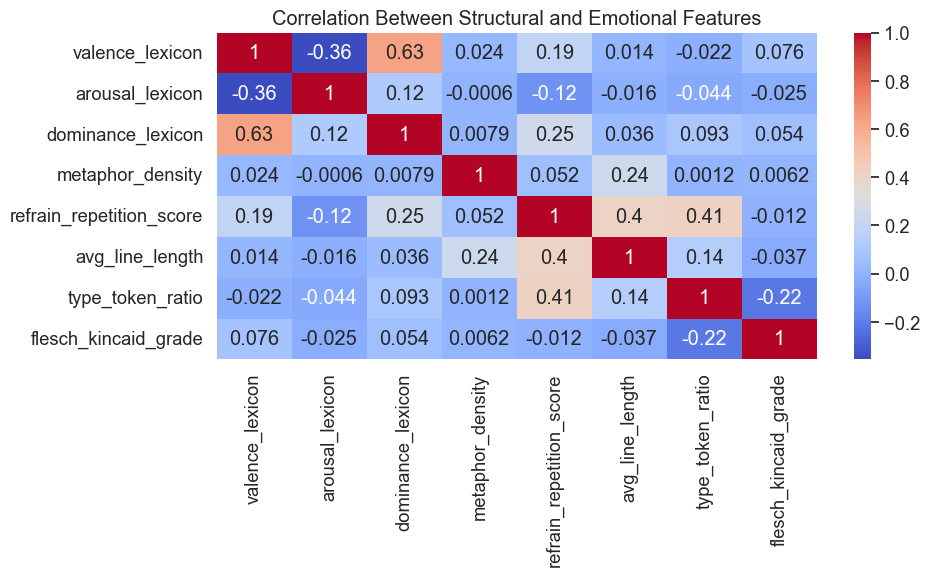

🧠 Plotting metaphor density vs. VAD direction...


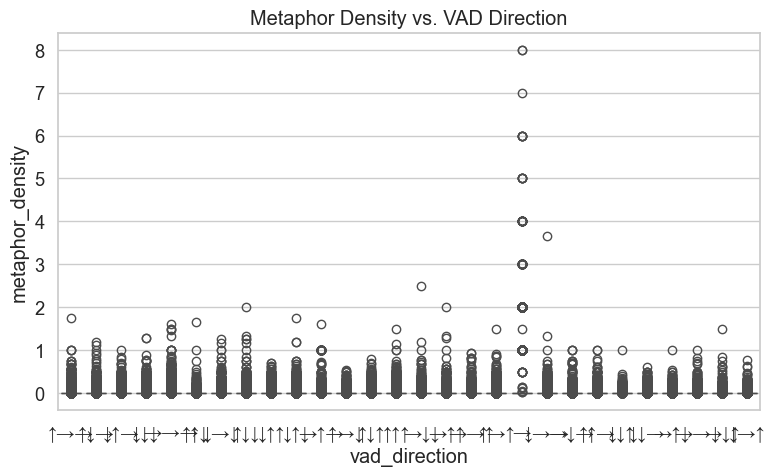

🔁 Plotting repetition score by dominance level...


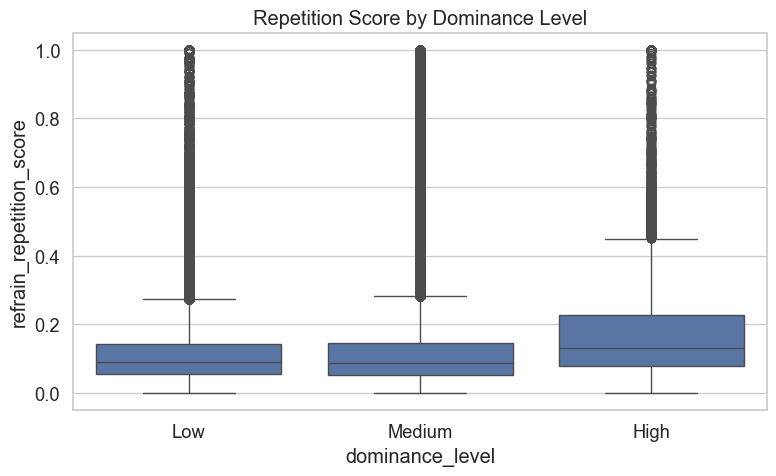

✅ All plots generated.


In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# print("📂 Loading datasets...")
# df_struct = pd.read_csv("dataset/lyrics_structural_features_extended.csv").drop(columns=["lyrics"])
# df_traj = pd.read_csv("dataset/lyrics_vad_trajectory.csv").drop(columns=["lyrics"])

# print("🔗 Merging structural and trajectory features...")
# df = pd.concat([df_struct, df_traj], axis=1)
df = pd.read_csv("dataset/lyrics_annotated_structure.csv")
# print("🎯 Sampling 20,000 rows for analysis...")
# df = df.sample(20000, random_state=42)

print("🧮 Deriving metaphor density...")
df["metaphor_density"] = df["simile_count"] / df["line_count"]

print("📊 Binning dominance levels...")
df["dominance_level"] = pd.cut(df["dominance_lexicon"], bins=[0, 0.4, 0.65, 1.0], labels=["Low", "Medium", "High"])

# Correlation matrix
print("📈 Plotting correlation heatmap...")
corr_vars = [
    "valence_lexicon", "arousal_lexicon", "dominance_lexicon",
    "metaphor_density", "refrain_repetition_score",
    "avg_line_length", "type_token_ratio", "flesch_kincaid_grade"
]
plt.figure(figsize=(10, 6))
sns.heatmap(df[corr_vars].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Structural and Emotional Features")
plt.tight_layout()
plt.show()

# Boxplot: Metaphor density across valence direction
print("🧠 Plotting metaphor density vs. VAD direction...")
plt.figure(figsize=(8, 5))
sns.boxplot(x="vad_direction", y="metaphor_density", data=df)
plt.title("Metaphor Density vs. VAD Direction")
plt.tight_layout()
plt.show()

# Boxplot: Repetition vs. dominance
print("🔁 Plotting repetition score by dominance level...")
plt.figure(figsize=(8, 5))
sns.boxplot(x="dominance_level", y="refrain_repetition_score", data=df)
plt.title("Repetition Score by Dominance Level")
plt.tight_layout()
plt.show()

print("✅ All plots generated.")

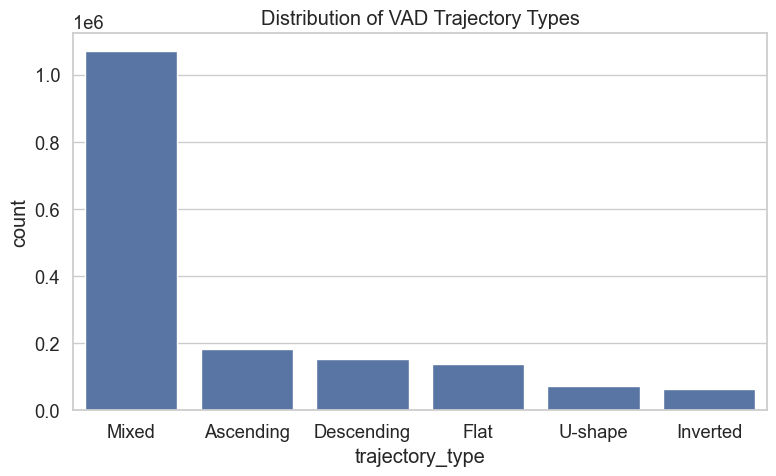

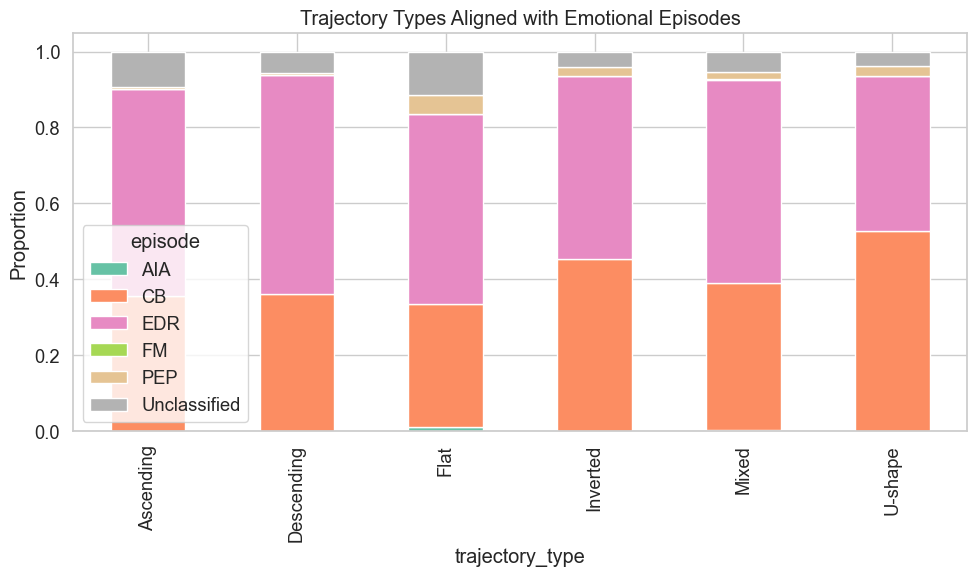

In [82]:
# Symbolic VAD trajectory types
def label_trajectory(direction):
    if direction == "↓↑→":
        return "U-shape"
    elif direction == "↑↓→":
        return "Inverted"
    elif direction.count("↑") == 3:
        return "Ascending"
    elif direction.count("↓") == 3:
        return "Descending"
    elif direction == "→→→":
        return "Flat"
    else:
        return "Mixed"

df["trajectory_type"] = df["vad_direction"].apply(label_trajectory)

# Barplot: Frequency of trajectory types
plt.figure(figsize=(8, 5))
sns.countplot(x="trajectory_type", data=df, order=df["trajectory_type"].value_counts().index)
plt.title("Distribution of VAD Trajectory Types")
plt.tight_layout()
plt.show()

# Cross-tab trajectory type × episode (if available)
if "episode" in df.columns:
    crosstab = pd.crosstab(df["trajectory_type"], df["episode"], normalize="index")
    crosstab.plot(kind="bar", stacked=True, colormap="Set2", figsize=(10, 6))
    plt.title("Trajectory Types Aligned with Emotional Episodes")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

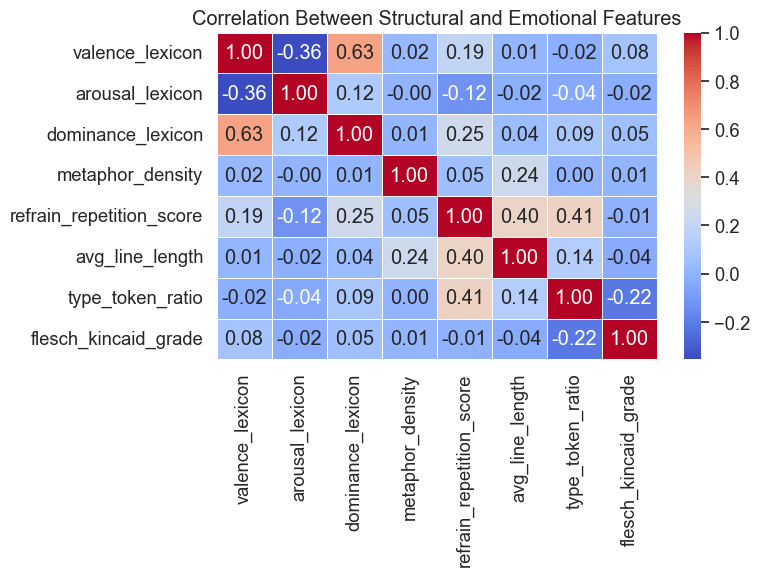

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: correlation of these columns
feature_cols = [
    "valence_lexicon", "arousal_lexicon", "dominance_lexicon",
    "metaphor_density", "refrain_repetition_score", "avg_line_length",
    "type_token_ratio", "flesch_kincaid_grade"
]

# Subset your DataFrame
df_sub = df[feature_cols].dropna()

# Compute correlation
corr = df_sub.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Between Structural and Emotional Features")
plt.tight_layout()
plt.show()

        episode  type_token_ratio  metaphor_density  refrain_repetition_score  \
0           AIA          0.443588          0.000129                  0.124953   
1            CB          0.417382          0.006856                  0.106660   
2           EDR          0.428049          0.006382                  0.176798   
3            FM          0.404412          0.000139                  0.211490   
4           PEP          0.436573          0.000077                  0.119008   
5  Unclassified          0.375317          0.004459                  0.147482   

   first_person_pronouns  avg_line_length  negation_count  
0               3.664519         5.452982        0.772299  
1              15.236150         8.155023        2.394881  
2              14.808857         8.402412        2.093839  
3               3.245583         5.518723        1.130742  
4               1.772847         6.737155        1.599693  
5              13.411817         6.481418        2.000379  


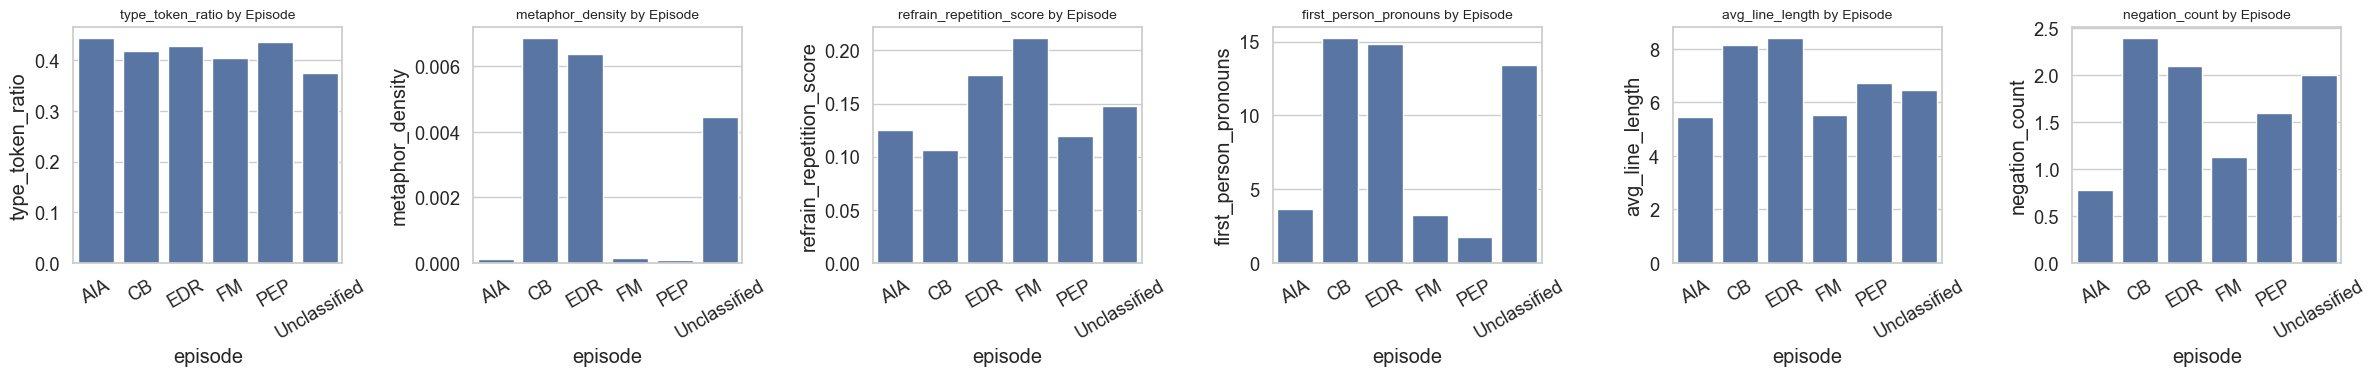

In [84]:
# Suppose df has 'episode' column (song-level or aggregated line-level episodes).
# We'll group by 'episode' and compute the average of each structural–linguistic feature.

episode_features = [
    "type_token_ratio", "metaphor_density", "refrain_repetition_score",
    "first_person_pronouns", "avg_line_length", "negation_count"
]

df_episode_signature = (
    df.groupby("episode")[episode_features]
    .mean()
    .reset_index()
)

print(df_episode_signature)

# You can also do a barplot for each feature across episodes:
import numpy as np

num_feats = len(episode_features)
fig, axes = plt.subplots(1, num_feats, figsize=(4*num_feats, 4), sharey=False)

for i, feat in enumerate(episode_features):
    sns.barplot(x="episode", y=feat, data=df_episode_signature, ax=axes[i])
    axes[i].set_title(f"{feat} by Episode", fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [89]:
from sklearn.cluster import KMeans
# or from hdbscan import HDBSCAN

# Choose a subset of structural–linguistic columns for clustering
cluster_features = [
    "type_token_ratio", "metaphor_density", "refrain_repetition_score",
    "avg_line_length", "flesch_kincaid_grade"
]

df_cluster = df[cluster_features].dropna()
# Optional: scale features
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(df_cluster)

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df["cluster_id"] = kmeans.fit_predict(X)

# Summarize cluster composition by episodes
if "episode" in df.columns:
    cluster_summary = df.groupby(["cluster_id", "episode"]).size().unstack(fill_value=0)
    print(cluster_summary)

episode      AIA      CB     EDR   FM    PEP  Unclassified
cluster_id                                                
0           1487  232908  319043  272  12078         48615
1           2031  258012  288171  191  14515         29941
2             38    4079   66001   28    348          1500
3            478  145726  214228   73   4886         25277
4              2    4746    5001    2     81           214


In [91]:
def episode_signature_discovery(df, episode_col="episode", feature_cols=None):
    """
    Groups the dataset by 'episode' and computes average (or median) of each feature.
    Returns a summary DataFrame showing typical linguistic markers per episode.
    """
    if feature_cols is None:
        feature_cols = [
            "type_token_ratio", "metaphor_density", "first_person_pronouns",
            "negation_count", "question_count", "exclamation_count"
        ]
    
    # Group by episode and compute mean feature values
    signature_df = (
        df.groupby(episode_col)[feature_cols]
        .mean()
        .reset_index()
    )
    return signature_df

# Usage:
signature_df = episode_signature_discovery(df, episode_col="episode")
print(signature_df)

        episode  type_token_ratio  metaphor_density  first_person_pronouns  \
0           AIA          0.443588          0.000129               3.664519   
1            CB          0.417382          0.006856              15.236150   
2           EDR          0.428049          0.006382              14.808857   
3            FM          0.404412          0.000139               3.245583   
4           PEP          0.436573          0.000077               1.772847   
5  Unclassified          0.375317          0.004459              13.411817   

   negation_count  question_count  exclamation_count  
0        0.772299        0.808226           1.388503  
1        2.394881        1.258735           1.255629  
2        2.093839        0.999653           0.567293  
3        1.130742        0.464664           1.660777  
4        1.599693        0.802213           1.638774  
5        2.000379        0.870939           0.882384  


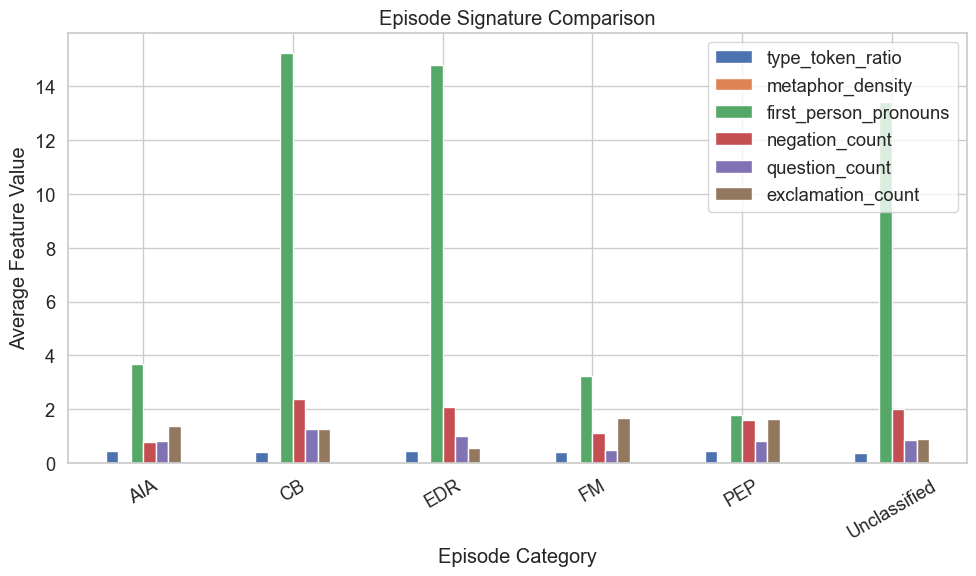

In [93]:
import matplotlib.pyplot as plt

def plot_episode_signatures(signature_df, episode_col="episode"):
    signature_df.plot(x=episode_col, kind="bar", figsize=(10,6))
    plt.title("Episode Signature Comparison")
    plt.xlabel("Episode Category")
    plt.ylabel("Average Feature Value")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
plot_episode_signatures(signature_df)

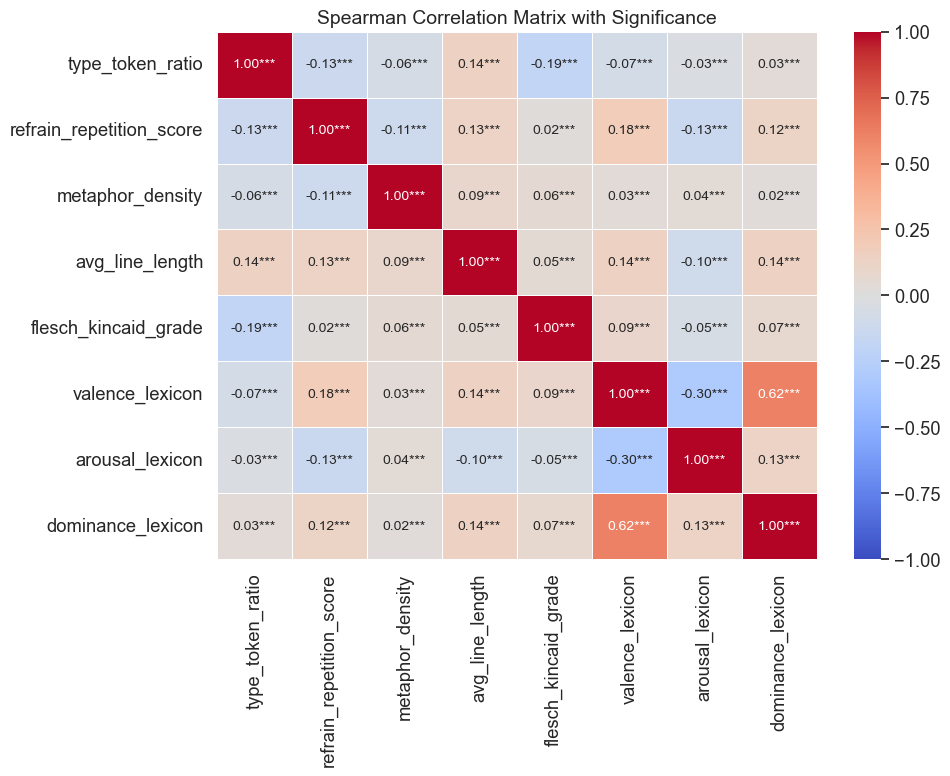

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# Suppose you already have your DataFrame 'df' with your features.
# Define the list of structural features and VAD dimensions:
feature_cols = [
    "type_token_ratio", "refrain_repetition_score", "metaphor_density",
    "avg_line_length", "flesch_kincaid_grade"
]
vad_cols = ["valence_lexicon", "arousal_lexicon", "dominance_lexicon"]

# Create a subset of your DataFrame
cols_to_analyze = feature_cols + vad_cols
df_sub = df[cols_to_analyze].dropna()

# Compute Spearman correlation and corresponding p-values
rho, pvals = spearmanr(df_sub)
rho_df = pd.DataFrame(rho, index=cols_to_analyze, columns=cols_to_analyze)
pval_df = pd.DataFrame(pvals, index=cols_to_analyze, columns=cols_to_analyze)

# Function to convert a p-value into significance stars
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# Build an annotation DataFrame combining correlation coefficients and significance stars
annot_df = rho_df.copy().round(2).astype(str)
for i in range(rho_df.shape[0]):
    for j in range(rho_df.shape[1]):
        annot_df.iloc[i, j] = f"{rho_df.iloc[i,j]:.2f}{significance_stars(pval_df.iloc[i,j])}"

# Plot the heatmap with no extra formatting (fmt="" prevents re-formatting our strings)
plt.figure(figsize=(10, 8))
sns.heatmap(rho_df, annot=annot_df, fmt="", cmap="coolwarm", vmin=-1, vmax=1, 
            linewidths=0.5, annot_kws={"size": 10})
plt.title("Spearman Correlation Matrix with Significance", fontsize=14)
plt.tight_layout()
plt.show()

# > 🌍 Stage 4: Cross-Cultural & Genre Analysis

**8. Language & Genre Effects**
Compare VAD and episode distributions:
- Across languages (e.g., English vs. Spanish vs. Chinese)
- Across genres (e.g., pop, hip hop, folk, classical)
Use:
- Kruskal-Wallis / ANOVA
- Multivariate regression
- t-SNE / PCA visualizations

Publishable insight: “Pop music in X culture emphasizes AIA while hip hop in Y culture emphasizes FM/PEP.”




# > 🧱 Stage 5: Framework Design (Optional)

**9. Build a Scalable Annotation–Episode Mapping Framework**

Now that you have dynamic episode sequences, you can:
- 🎞️ Visualize episode transitions within songs (like emotional storylines)
- 📊 Compare trajectory patterns across genres/languages
- 🧠 Cluster trajectory types (e.g., U-shape, inverted, flat, rising)
- 📝 Train models to predict episodes from structure
